# Student Grade Predictor

This is my first machine learning project. The goal is to predict students' final grade (`G3`) and also understand how much the previous grades (`G1` and `G2`) affect prediction quality.

Dataset: UCI Student Performance dataset  
Problem type: supervised learning - regression


## 1. Dataset and Setup

I start by importing the libraries used in the notebook and loading the student performance dataset.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


### Initial Dataset Inspection

Before training any model, I inspect the dataset shape, columns, data types, and a few example rows to understand what features are available.


In [ ]:
student_dataset = pd.read_csv("student-mat.csv",sep=";")

In [ ]:
# print("Shape:", student_dataset.shape)
# print(student_dataset.columns)
# print("Data types:")
#print(student_dataset.dtypes)
student_dataset.head(20)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


## 2. Data Quality Checks

I check for missing values and duplicate rows. Both checks show no issues in this dataset, so I continue without cleaning or removing rows.


In [ ]:
student_dataset.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
student_dataset.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

I use summary statistics and plots to get a better sense of the target variable and a few features that may be related to final grades.


In [ ]:
student_dataset.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### G3 Summary

`G3` is the final grade and the target variable for this project. The values range from 0 to 20.


In [ ]:
student_dataset["G3"].describe()

,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000


### Distribution of Final Grades

The histogram shows how final grades are distributed across the dataset. Most grades are around the middle of the scale, but there are also several students with `G3 = 0`.


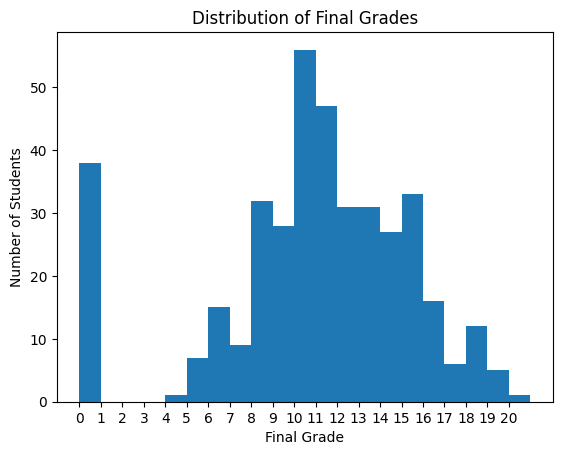

In [ ]:
plt.hist(student_dataset["G3"],bins=range(0, 22))
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.xticks(range(0, 21))
plt.show()

### Zero Final Grades

I noticed that some students have a final grade of 0. I checked these rows separately because they may be harder for a regression model to predict, especially when earlier grades are not also zero.


In [ ]:
zero_count = (student_dataset["G3"] == 0).sum()
print(f"number of zero G3 {zero_count}")
print(f"precentage {zero_count*100/len(student_dataset["G3"])}")
zero_countG2 = (student_dataset["G2"] == 0).sum()
zero_countG1 = (student_dataset["G1"] == 0).sum()
print(f"G1 0 is {zero_countG1} \nG2 0 is {zero_countG2}")
zero_students = student_dataset[student_dataset["G3"] == 0]
zero_students[["G1", "G2", "G3"]].head(20)

number of zero G3 38
precentage 9.620253164556962
G1 0 is 0 
G2 0 is 13


,G1,G2,G3
128,7,4,0
130,12,0,0
131,8,0,0
134,9,0,0
135,11,0,0
136,10,0,0
137,4,0,0
140,7,9,0
144,5,0,0
146,6,7,0


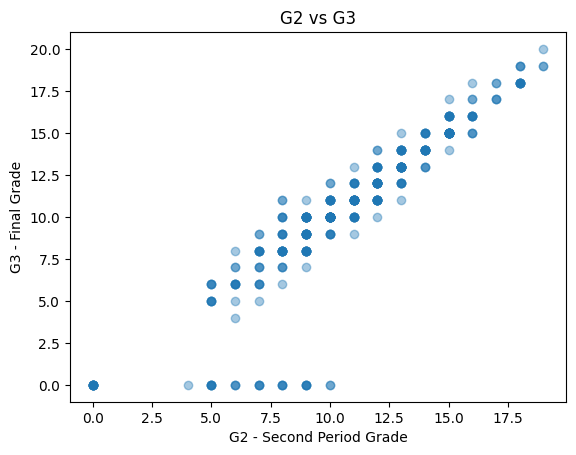

,G2,G3
G2,1.000000,0.904868
G3,0.904868,1.000000


In [ ]:
plt.scatter(student_dataset["G2"], student_dataset["G3"],alpha=0.4)
plt.xlabel("G2 - Second Period Grade")
plt.ylabel("G3 - Final Grade")
plt.title("G2 vs G3")
plt.show()
student_dataset[["G2", "G3"]].corr()

In [ ]:
features = ["studytime", "absences", "failures", "G3"]
student_dataset[features].corr()

,studytime,absences,failures,G3
studytime,1.000000,-0.062700,-0.173563,0.097820
absences,-0.062700,1.000000,0.063726,0.034247
failures,-0.173563,0.063726,1.000000,-0.360415
G3,0.097820,0.034247,-0.360415,1.000000


### Study Time

I compare average final grade by study time category and also check how many students are in each category.


In [ ]:
student_dataset.groupby("studytime")["G3"].mean()


,G3
studytime,
1,10.047619
2,10.171717
3,11.400000
4,11.259259


In [ ]:
student_dataset.groupby("studytime")["G3"].count()


,G3
studytime,
1,105
2,198
3,65
4,27


Study time has only a weak positive relationship with the final grade. The average score increases from categories 1 to 3 and stays similar in category 4, but this does not prove a causal effect.


### Previous Failures

I check whether the number of previous failures is related to the final grade.


In [ ]:
mean_failures=student_dataset.groupby("failures")["G3"].mean()

In [ ]:
count_faiilures=student_dataset.groupby("failures")["G3"].count()
student_dataset.groupby("failures")["G3"].count()

,G3
failures,
0,312
1,50
2,17
3,16


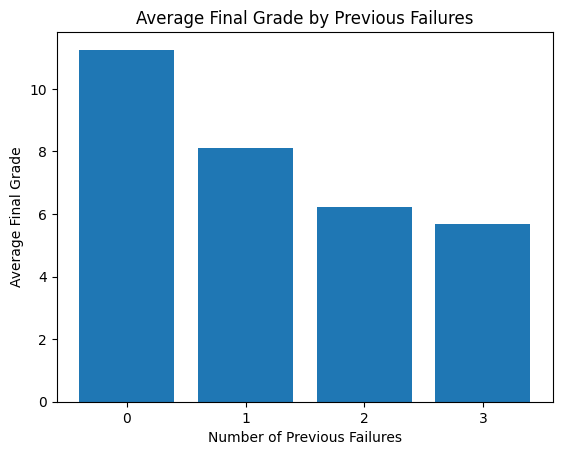

In [ ]:
plt.bar(mean_failures.index,mean_failures.values)
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Previous Failures")

plt.xticks(mean_failures.index)

plt.show()

Students with more previous failures tend to have lower final grades. The groups with 2 or 3 failures are much smaller, so I interpret those averages carefully.


### Absences

I use a scatter plot to check whether absences have a clear linear relationship with `G3`.


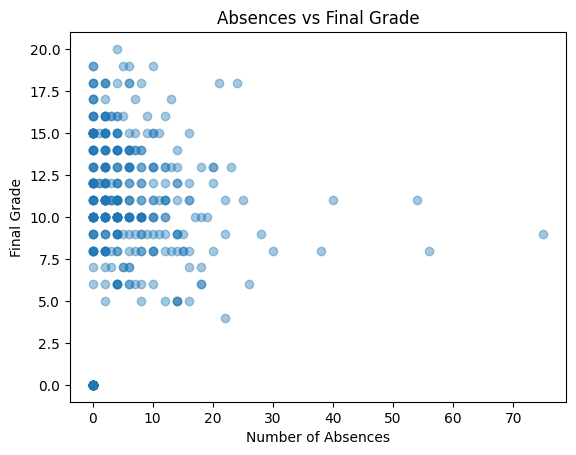

In [ ]:
plt.scatter(
    student_dataset["absences"],
    student_dataset["G3"],
    alpha=0.4
)

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")
plt.show()

There is no clear linear relationship between the number of absences and the final grade in this plot.


## 4. Experiment 1 - Early Grade Prediction

In the first experiment, I intentionally remove `G1` and `G2`. The question is whether `G3` can be predicted from demographic, social, school, and behavioral features before previous period grades are available.


In [ ]:
X = student_dataset.drop(["G1","G2","G3"],axis=1)
y = student_dataset["G3"]
print(X.shape)
print(y.shape)

(395, 30)
(395,)


I split the data into 70% train, 15% validation, and 15% test. The test set is kept separate for final evaluation.


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(276, 30)
(59, 30)
(60, 30)


In [ ]:
X_train.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [ ]:
categorical_columns = X_train.select_dtypes(include="object").columns

print(categorical_columns)
print("Number of categorical columns:", len(categorical_columns))
numeric_columns = X_train.select_dtypes(include="number").columns
print(numeric_columns)
print("Number of categorical columns:", len(numeric_columns))
print("Total:", len(categorical_columns) + len(numeric_columns))

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')
Number of categorical columns: 17
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences'],
      dtype='object')
Number of categorical columns: 13
Total: 30


In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
"""
fit מול transform

fit() = ללמוד את החוקים

"ראיתי שב־sex קיימות הקטגוריות F ו־M."

transform() = להשתמש בחוקים

"עכשיו קיבלתי M, אז אמיר אותו ל־0,1."
"""
encoder.fit(X_train[categorical_columns])
X_train_encoded = encoder.transform(X_train[categorical_columns])

X_val_encoded = encoder.transform(X_val[categorical_columns])

X_test_encoded = encoder.transform(X_test[categorical_columns])
print(X_train[categorical_columns].shape)
print(X_train_encoded.shape)
encoder.get_feature_names_out(categorical_columns)
X_train_transformed = np.concatenate((X_train_encoded,X_train[numeric_columns]),axis=1)
X_val_transformed = np.concatenate(
    (X_val_encoded, X_val[numeric_columns]),
    axis=1
)

X_test_transformed = np.concatenate(
    (X_test_encoded, X_test[numeric_columns]),
    axis=1
)
print(X_train_transformed.shape)
print(X_val_transformed.shape)
print(X_test_transformed.shape)

(276, 17)
(276, 43)
(276, 56)
(59, 56)
(60, 56)


### Manual Preprocessing and Baseline

For this first experiment, I manually preprocess the data as part of the learning process. Categorical features are one-hot encoded, numerical features are standardized, and the transformed parts are combined.

As a simple baseline, I predict the mean training grade for every validation example.


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train[numeric_columns])
X_train_numeric_scaled = scaler.transform(X_train[numeric_columns])
X_val_numeric_scaled = scaler.transform(X_val[numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[numeric_columns])
X_train_transformed = np.concatenate(
    (X_train_encoded, X_train_numeric_scaled),
    axis=1)
X_val_transformed = np.concatenate(
    (X_val_encoded, X_val_numeric_scaled),
    axis=1)
X_test_transformed = np.concatenate(
    (X_test_encoded, X_test_numeric_scaled),
    axis=1)
print(X_train_transformed.shape)
print(X_val_transformed.shape)
print(X_test_transformed.shape)


(276, 56)
(59, 56)
(60, 56)


In [ ]:
baseline_value = y_train.mean()
print(baseline_value)

10.456521739130435


In [ ]:
baseline_predictions = np.full(y_val.shape, baseline_value)
print(baseline_predictions.shape)


(59,)


In [ ]:
baseline_mae = mean_absolute_error(y_val, baseline_predictions)
print("mae is",baseline_mae)
baseline_mse = mean_squared_error(y_val, baseline_predictions)
print("Rmse is",np.sqrt(baseline_mse))


mae is 3.7888725128960945
Rmse is 4.895880934352259


### Linear Regression

After the baseline, I train a Linear Regression model on the manually preprocessed features and evaluate it on the validation set.


In [ ]:
model = LinearRegression()
model.fit(X_train_transformed, y_train)
"""
X = המידע שהמודל משתמש בו כדי ללמוד
y = התשובה הנכונה שהוא מנסה ללמוד לחזות
"""
val_predictions = model.predict(X_val_transformed)
print(val_predictions.shape)
print(val_predictions[:5])

(59,)
[ 8.60771784  9.44781267 14.20323917 13.26743432 10.77420977]


In [ ]:
linear_mae = mean_absolute_error(y_val, val_predictions)
print("mae is",linear_mae)
linear_mse = mean_squared_error(y_val,val_predictions)
print("Rmse is",np.sqrt(linear_mse))

mae is 3.533414073102631
Rmse is 4.517761972960119


### Error Analysis

I inspect the residuals and the largest absolute errors to understand where the Linear Regression model struggles.


In [ ]:
errors = y_val - val_predictions
errors.describe()

,G3
count,59.000000
mean,-0.852181
std,4.474745
min,-12.201326
25%,-3.755803
50%,0.343752
75%,2.183084
max,6.682374


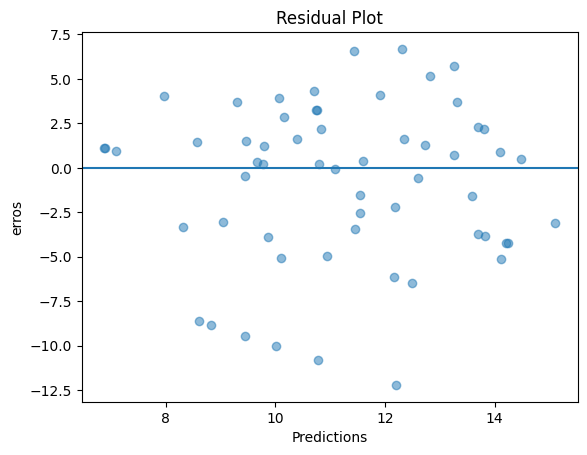

In [ ]:
plt.scatter(val_predictions, errors, alpha=0.5)

plt.axhline(y=0)

plt.xlabel("Predictions")
plt.ylabel("erros")
plt.title("Residual Plot")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": val_predictions,
    "Error": errors.values
})

results["Absolute Error"] = results["Error"].abs()

results.sort_values(
    "Absolute Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute Error
17,0,12.201326,-12.201326,12.201326
4,0,10.774210,-10.774210,10.774210
48,0,10.008048,-10.008048,10.008048
1,0,9.447813,-9.447813,9.447813
28,0,8.831020,-8.831020,8.831020
0,0,8.607718,-8.607718,8.607718
34,19,12.317626,6.682374,6.682374
21,18,11.436093,6.563907,6.563907
29,6,12.486538,-6.486538,6.486538
33,6,12.162007,-6.162007,6.162007


In [ ]:
(y_val == 0).sum()

np.int64(6)

Linear Regression using demographic, social, and school-related features struggled especially with students who received `G3 = 0`. All six zero-grade students in the validation set appeared among the ten largest prediction errors.


### Ridge Regression

Next I try Ridge Regression, which adds regularization to Linear Regression. I compare several alpha values using the validation set.


In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_transformed, y_train)
    ridge_val_predictions = ridge_model.predict(X_val_transformed)
    ridge_mae = mean_absolute_error(y_val,ridge_val_predictions)
    ridge_mse = mean_squared_error(y_val, ridge_val_predictions)
    ridge_rmse = np.sqrt(ridge_mse)
    print(f"Ridge MAE for alpha {alpha}", ridge_mae)
    print(f"Ridge RMSE alpha {alpha} ", ridge_rmse)

Ridge MAE for alpha 0.01 3.533334984445983
Ridge RMSE alpha 0.01  4.517633441710672
Ridge MAE for alpha 0.1 3.532627521088869
Ridge RMSE alpha 0.1  4.516486296768013
Ridge MAE for alpha 1 3.525952797785897
Ridge RMSE alpha 1  4.505897937417702
Ridge MAE for alpha 10 3.4826669971963105
Ridge RMSE alpha 10  4.449400814074802
Ridge MAE for alpha 100 3.4241421387862747
Ridge RMSE alpha 100  4.451562324223826


The first Ridge comparison suggests that larger alpha values may work better, so I test a few more values around that range.


In [ ]:
alphas = [2, 5, 10, 20, 50]
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_transformed, y_train)
    ridge_val_predictions = ridge_model.predict(X_val_transformed)
    ridge_mae = mean_absolute_error(y_val,ridge_val_predictions)
    ridge_mse = mean_squared_error(y_val, ridge_val_predictions)
    ridge_rmse = np.sqrt(ridge_mse)
    print(f"Ridge MAE for alpha {alpha}", ridge_mae)
    print(f"Ridge RMSE alpha {alpha} ", ridge_rmse)

Ridge MAE for alpha 2 3.5192818960363144
Ridge RMSE alpha 2  4.495758042759285
Ridge MAE for alpha 5 3.5027698956399536
Ridge RMSE alpha 5  4.4727520845226785
Ridge MAE for alpha 10 3.4826669971963105
Ridge RMSE alpha 10  4.449400814074802
Ridge MAE for alpha 20 3.4572489849826997
Ridge RMSE alpha 20  4.428393387030515
Ridge MAE for alpha 50 3.4261116279269515
Ridge RMSE alpha 50  4.424096883558398


## 5. Experiment 2 - Adding G1 and G2

The EDA showed a strong relationship between `G2` and `G3`, so I run a second experiment where `G1` and `G2` are included.

This is a different prediction scenario, not just a better version of the first model. Experiment 1 is early prediction without previous grades. Experiment 2 is later prediction when previous grades are already known.


In [ ]:
X_with_grades = student_dataset.drop(columns=["G3"])
y_with_grades = student_dataset["G3"]
print(X_with_grades.shape)
print(y_with_grades.shape)

(395, 32)
(395,)


In [ ]:
X_train_grades, X_temp_grades, y_train_grades, y_temp_grades = train_test_split(
    X_with_grades,
    y_with_grades,
    test_size=0.3,
    random_state=42
)
X_val_grades, X_test_grades, y_val_grades, y_test_grades = train_test_split(
    X_temp_grades,
    y_temp_grades,
    test_size=0.5,
    random_state=42
)
print(X_train_grades.shape)
print(X_val_grades.shape)
print(X_test_grades.shape)


(276, 32)
(59, 32)
(60, 32)


In [ ]:
categorical_columns_grades = X_train_grades.select_dtypes(include="object").columns
numeric_columns_grades = X_train_grades.select_dtypes(include="number").columns
print("Categorical:", len(categorical_columns_grades))
print("Numerical:", len(numeric_columns_grades))
print("Total:", len(categorical_columns_grades) + len(numeric_columns_grades))

Categorical: 17
Numerical: 15
Total: 32


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns_grades
        ),
        (
            "numerical",
            StandardScaler(),
            numeric_columns_grades
        )
    ]
)

This section uses `ColumnTransformer` and `Pipeline` to organize preprocessing and Ridge Regression together. In the first experiment I did the preprocessing manually; here the same kind of workflow is handled more cleanly by scikit-learn.

Including `G1` and `G2` gives much lower validation errors, so I compare alpha values again for this new setup.


In [ ]:
alphas = [0.1, 1, 10, 50, 100]
for alpha in alphas:
  model_with_grades = Pipeline([
      ("preprocessor", preprocessor),
      ("model", Ridge(alpha=alpha))
  ])
  model_with_grades.fit(X_train_grades, y_train_grades)
  grades_val_predictions = model_with_grades.predict(X_val_grades)
  grades_mae = mean_absolute_error(y_val_grades, grades_val_predictions)
  grades_mse = mean_squared_error(y_val_grades, grades_val_predictions)
  grades_rmse = np.sqrt(grades_mse)
  print(f"MAE for:{alpha} ", grades_mae)
  print(f"RMSE: {alpha} ", grades_rmse)

MAE for:0.1  1.5331266572069937
RMSE: 0.1  2.402873113015748
MAE for:1  1.5272299649634344
RMSE: 1  2.4015907981759073
MAE for:10  1.488646206197628
RMSE: 10  2.398101150426807
MAE for:50  1.4485654303305355
RMSE: 50  2.4270445294119942
MAE for:100  1.455877843768928
RMSE: 100  2.494362296841934


Validation RMSE is the main metric I use for alpha selection here, and alpha `10` gives the best RMSE in this comparison.


In [ ]:
model_with_grades = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])
model_with_grades.fit(X_train_grades, y_train_grades)
grades_val_predictions = model_with_grades.predict(X_val_grades)
print(grades_val_predictions.shape)
print(grades_val_predictions[:5])

(59,)
[ 8.00214175  5.27091979  9.55582006 20.30154282  7.66727447]


In [ ]:
grades_mae = mean_absolute_error(y_val_grades, grades_val_predictions)

grades_mse = mean_squared_error(y_val_grades, grades_val_predictions)
grades_rmse = np.sqrt(grades_mse)

print("MAE:", grades_mae)
print("RMSE:", grades_rmse)

MAE: 1.488646206197628
RMSE: 2.398101150426807


## 6. Final Model

After choosing the model setup and alpha value, I combine the train and validation data. The final Pipeline is trained on this combined data, while the test set remains untouched until the final evaluation.


In [ ]:
X_train_final = pd.concat([X_train_grades , X_val_grades])
y_train_final = pd.concat([y_train_grades , y_val_grades])
print(X_train_final.shape)
print(y_train_final.shape)

(335, 32)
(335,)


In [ ]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])
final_model.fit(X_train_final, y_train_final)
test_predictions = final_model.predict(X_test_grades)
test_mae = mean_absolute_error(y_test_grades,test_predictions)
test_mse = mean_squared_error(y_test_grades,test_predictions)
test_rmse = np.sqrt(test_mse)

print("Final Test MAE:", test_mae)
print("Final Test RMSE:", test_rmse)

Final Test MAE: 1.4456897845757115
Final Test RMSE: 2.019303375378079


## 7. Predicting a New Student

I create one example student and use the final model to predict the student's final grade. Because preprocessing and Ridge Regression are stored in one Pipeline, I can pass the raw student features directly to the model.


In [ ]:
new_student = {
    "school": "GP",
    "sex": "M",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "T",
    "Medu": 3,
    "Fedu": 3,
    "Mjob": "services",
    "Fjob": "services",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 1,
    "studytime": 2,
    "failures": 0,
    "schoolsup": "no",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 3,
    "Dalc": 1,
    "Walc": 2,
    "health": 4,
    "absences": 4,
    "G1": 13,
    "G2": 14
}
new_student_df = pd.DataFrame([new_student])
print(new_student_df.shape)
new_student_df

(1, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,M,17,U,GT3,T,3,3,services,services,...,no,4,3,3,1,2,4,4,13,14


In [ ]:
prediction = final_model.predict(new_student_df)
print(prediction)

[13.65445473]


In [ ]:
def predict_student(student):
    student_df = pd.DataFrame([student])
    prediction = final_model.predict(student_df)

    return prediction[0]

## 8. Saving the Model

I use `joblib` to save the trained Pipeline. This saves both the preprocessing steps and the Ridge model together.


In [ ]:
import joblib

In [ ]:
joblib.dump(final_model, "student_grade_model.joblib")

['student_grade_model.joblib']

### Verify Saved Model

I load the saved model again and use it for prediction to check that the saved artifact works.


In [ ]:
loaded_model = joblib.load("student_grade_model.joblib")
loaded_prediction = loaded_model.predict(new_student_df)

print(loaded_prediction)

[13.65445473]


## 9. Conclusion

In this project, I compared a baseline, Linear Regression, and Ridge Regression for predicting final student grades. Without `G1` and `G2`, the model improved only moderately over the baseline. The error analysis also showed that zero final grades were especially difficult to predict from the available early features.

Adding `G1` and `G2` produced a large improvement, with final test results of about MAE = 1.45 and RMSE = 2.02. The two experiments represent different use cases: early prediction before previous grades are available, and later prediction after previous grades are known. This project gave me practical experience with EDA, preprocessing, train/validation/test separation, regression, regularization, hyperparameter tuning, pipelines, evaluation, and saving a trained model.
